In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set up paths
data_dir = Path('../data/processed')

# Load the Gaia catalog with proper motion
print("Loading Gaia catalog with proper motion...")
gaia_pm = pd.read_parquet(data_dir / 'eb_catalog_with_pm.parquet')
print(f"Gaia PM catalog shape: {gaia_pm.shape}")

# Load the Pan-STARRS photometry with temperatures
print("Loading Pan-STARRS photometry with temperatures...")
panstarrs_temp = pd.read_parquet(data_dir / 'gaia_eb_panstarrs_phot_with_temperatures.parquet')
print(f"Pan-STARRS temperature catalog shape: {panstarrs_temp.shape}")

# Join the tables on original_ext_source_id
print("Joining tables on original_ext_source_id...")
merged = gaia_pm.merge(panstarrs_temp, on='original_ext_source_id', how='inner')
print(f"Merged catalog shape: {merged.shape}")

print(f"\nMerged catalog columns: {len(merged.columns)}")
print(f"Available temperature measurements:")
print(f"  Te_avg != -999.0: {(merged['Te_avg'] != -999.0).sum():,} objects")
print(f"  Te_gr != -999.0: {(merged['Te_gr'] != -999.0).sum():,} objects")
print(f"  Te_ri != -999.0: {(merged['Te_ri'] != -999.0).sum():,} objects")
print(f"  Te_iz != -999.0: {(merged['Te_iz'] != -999.0).sum():,} objects")

merged.head()

Loading Gaia catalog with proper motion...
Gaia PM catalog shape: (1230649, 15)
Loading Pan-STARRS photometry with temperatures...
Pan-STARRS temperature catalog shape: (1172535, 22)
Joining tables on original_ext_source_id...
Merged catalog shape: (1172580, 36)

Merged catalog columns: 36
Available temperature measurements:
  Te_avg != -999.0: 1,172,047 objects
  Te_gr != -999.0: 1,156,887 objects
  Te_ri != -999.0: 1,133,567 objects
  Te_iz != -999.0: 1,133,752 objects


,source_id,clean_panstarrs1_oid,original_ext_source_id,l,b,pmra,pmdec,pseudocolour,phot_g_mean_mag,phot_bp_mean_mag,...,yPSFMagErr,filter_encoding,g_r_color,r_i_color,i_z_color,Te_gr,Te_ri,Te_iz,Te_avg,temp_measurement_count
0,46626164993792,967166606,108690456271144410,176.988972,-48.049800,2.203996,-6.068640,NaN,19.931410,20.556221,...,0.040987,griz,0.432299,0.170500,0.038700,5729.909939,5260.390367,5598.938292,5529.746199,3
1,104487964717440,972259318,108950446169939982,175.688254,-48.616774,-1.782626,-18.938406,NaN,17.909193,19.156775,...,0.002566,griz,1.231128,0.992235,0.363558,4035.351160,2821.296572,3786.527774,3547.725169,3
2,138577120584320,978183638,109270450082003814,175.823945,-48.154829,0.259084,-0.413995,NaN,15.532284,15.748469,...,0.002085,griz,0.357201,0.074599,0.171000,5965.409526,5850.695406,4685.570589,5500.558507,3
3,160219460292352,973703324,109030455555466575,176.608400,-47.903013,2.130611,-6.538687,NaN,17.597319,18.101242,...,0.004374,griz,0.554600,0.332001,0.097198,5383.780145,4496.399916,5154.649759,5011.609940,3
4,203551385701760,982701946,109510460340003115,176.680029,-47.283171,-21.000783,-43.917424,NaN,13.413368,14.149869,...,0.000436,griz,0.818900,0.160200,0.381200,4762.112580,5318.016770,3721.113012,4600.414120,3


Objects with both Gaia T_eff and Pan-STARRS Te_avg: 719,828


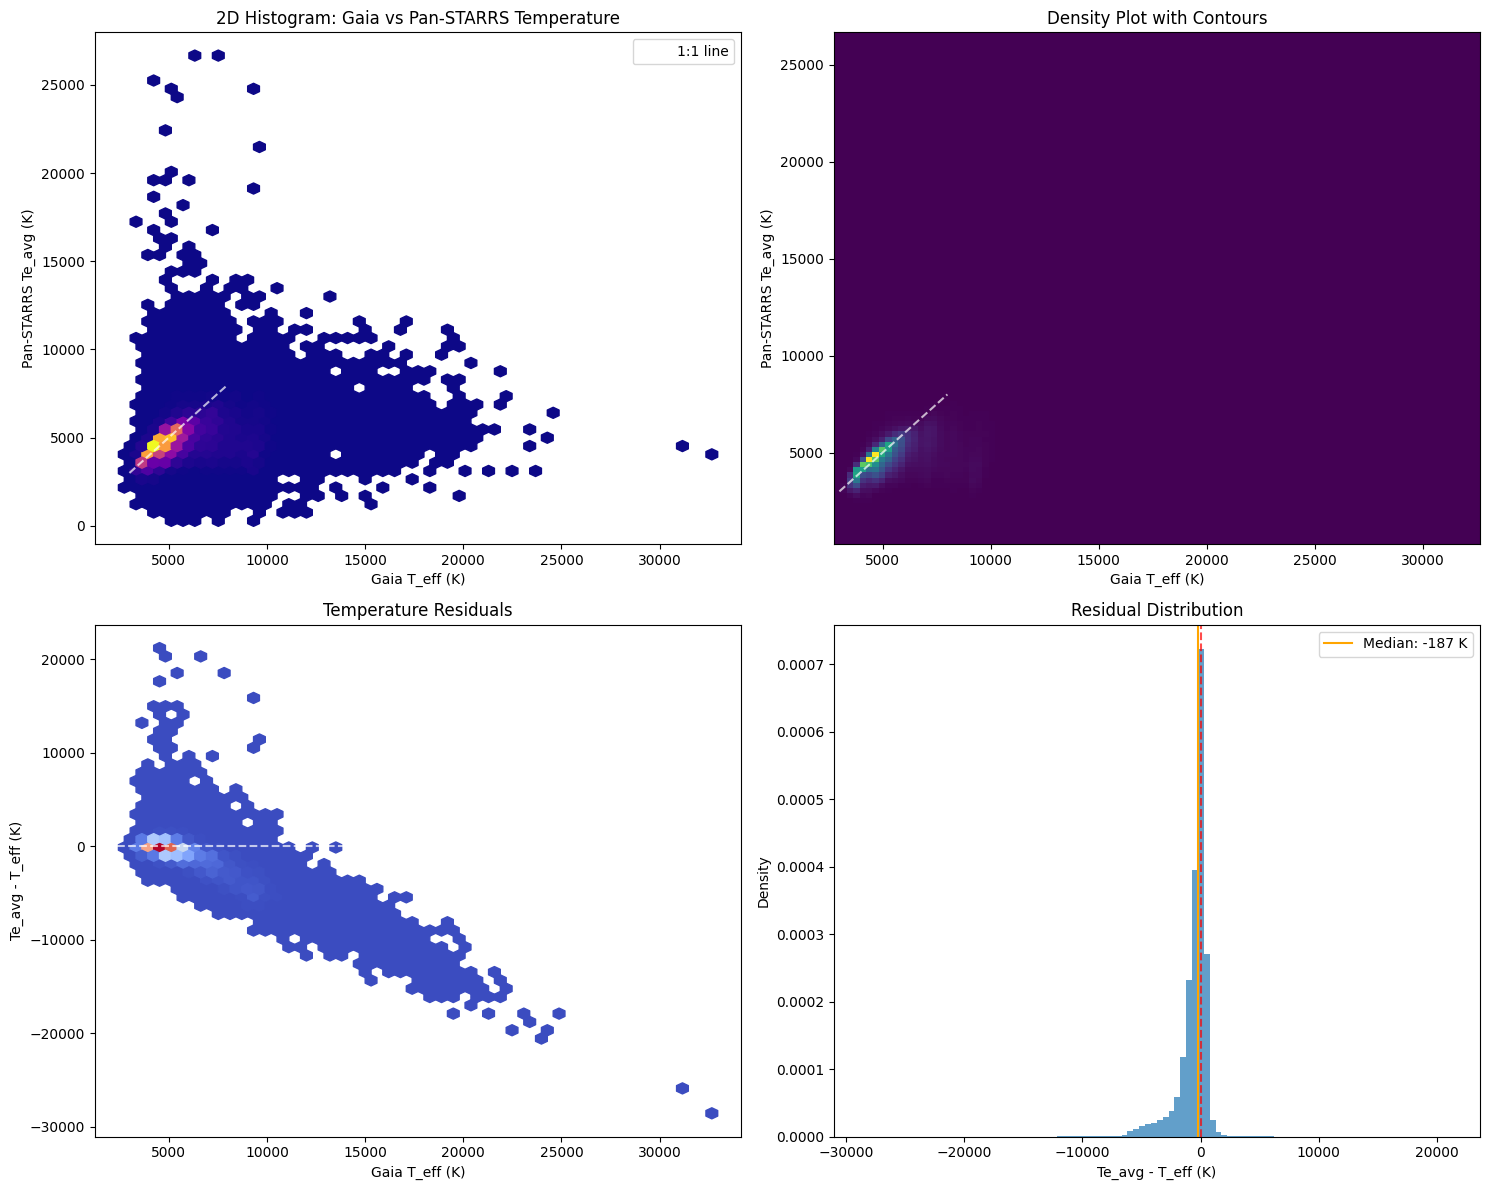


Temperature comparison statistics:
Gaia T_eff range: 2737 - 32657 K
Pan-STARRS Te_avg range: 285 - 26667 K
Median residual (Te_avg - T_eff): -187 K
MAD residual: 437 K
RMS residual: 1416 K


In [2]:
# Plot Gaia T_eff vs Pan-STARRS Te_avg
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_avg'] != -999.0)
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Pan-STARRS Te_avg: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_avg'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Pan-STARRS Te_avg (K)')
axes[0,0].set_title('2D Histogram: Gaia vs Pan-STARRS Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_avg'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Pan-STARRS Te_avg (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_avg'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_avg - T_eff (K)')
axes[1,0].set_title('Temperature Residuals')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_avg - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics:")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Pan-STARRS Te_avg range: {temp_data['Te_avg'].min():.0f} - {temp_data['Te_avg'].max():.0f} K")
print(f"Median residual (Te_avg - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")

Objects with both Gaia T_eff and Pan-STARRS Te_gr: 714,112


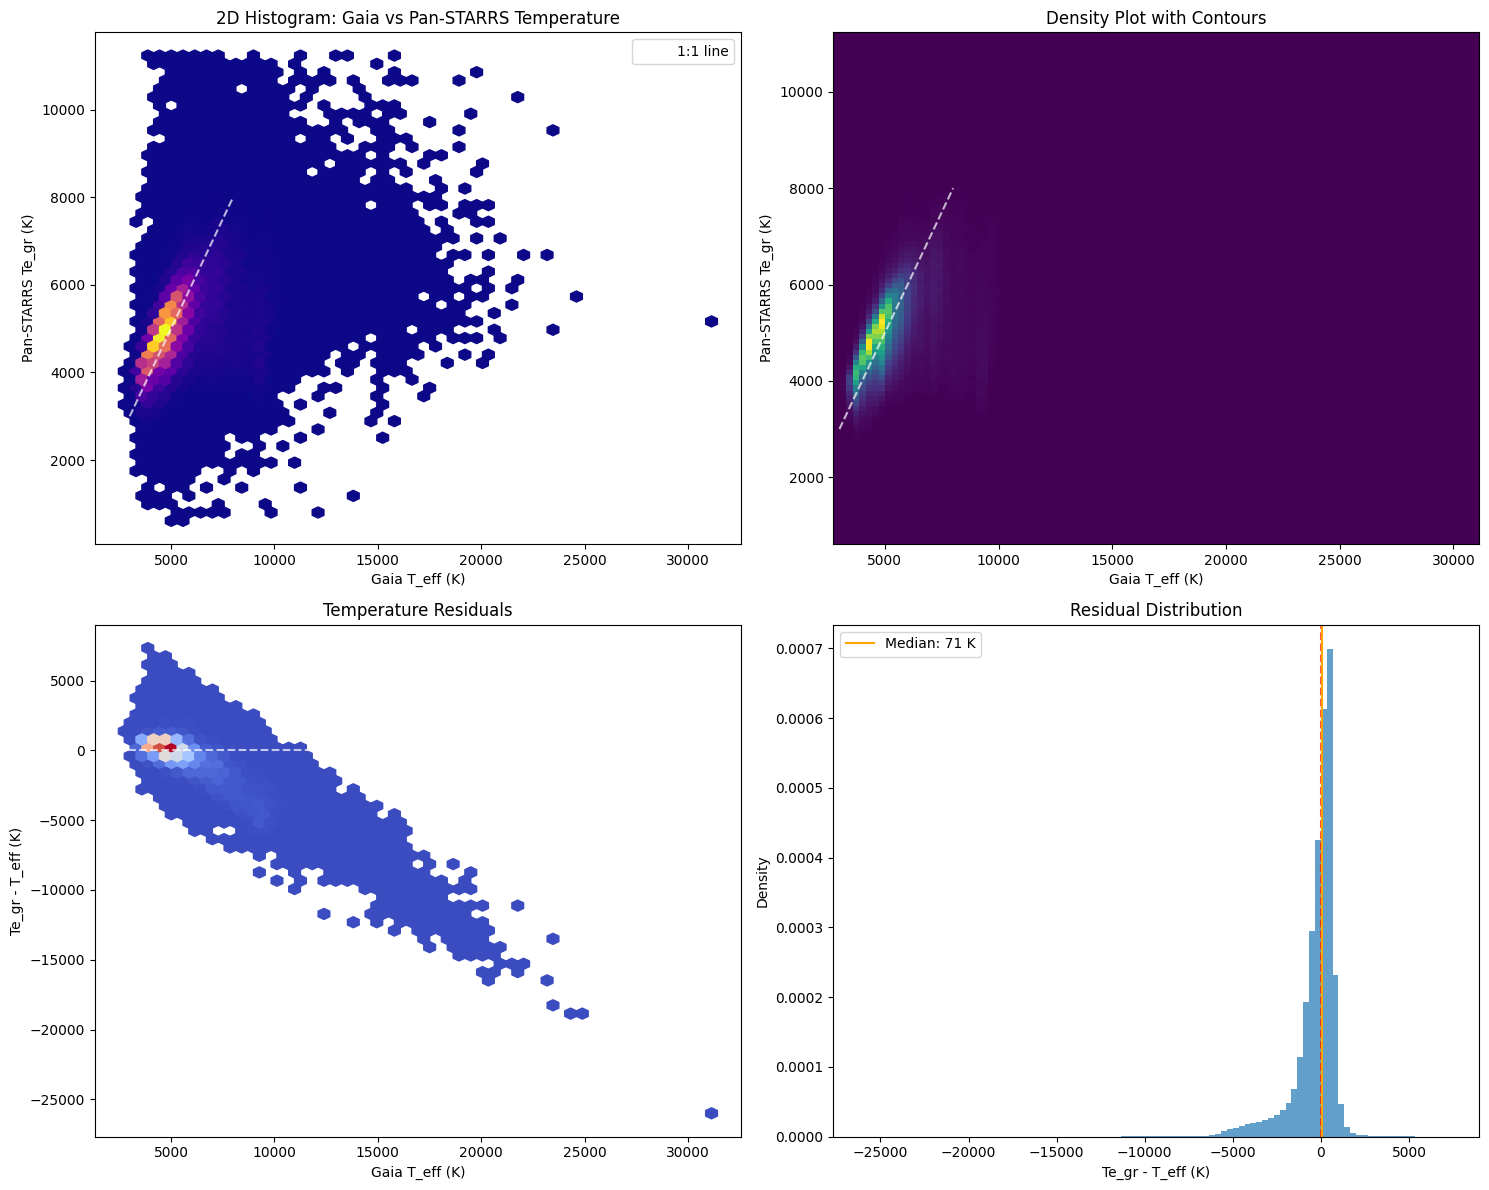


Temperature comparison statistics:
Gaia T_eff range: 2737 - 31144 K
Pan-STARRS Te_gr range: 614 - 11235 K
Median residual (Te_gr - T_eff): 71 K
MAD residual: 442 K
RMS residual: 1269 K


In [ ]:
# Plot Gaia T_eff vs Pan-STARRS Te_gr
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_gr'] != -999.0)
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Pan-STARRS Te_gr: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_gr'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Pan-STARRS Te_gr (K)')
axes[0,0].set_title('2D Histogram: Gaia vs Pan-STARRS Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_gr'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Pan-STARRS Te_gr (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_gr'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_gr - T_eff (K)')
axes[1,0].set_title('Temperature Residuals')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_gr - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics:")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Pan-STARRS Te_gr range: {temp_data['Te_gr'].min():.0f} - {temp_data['Te_gr'].max():.0f} K")
print(f"Median residual (Te_gr - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")

Objects with both Gaia T_eff and Pan-STARRS Te_ri: 707,714


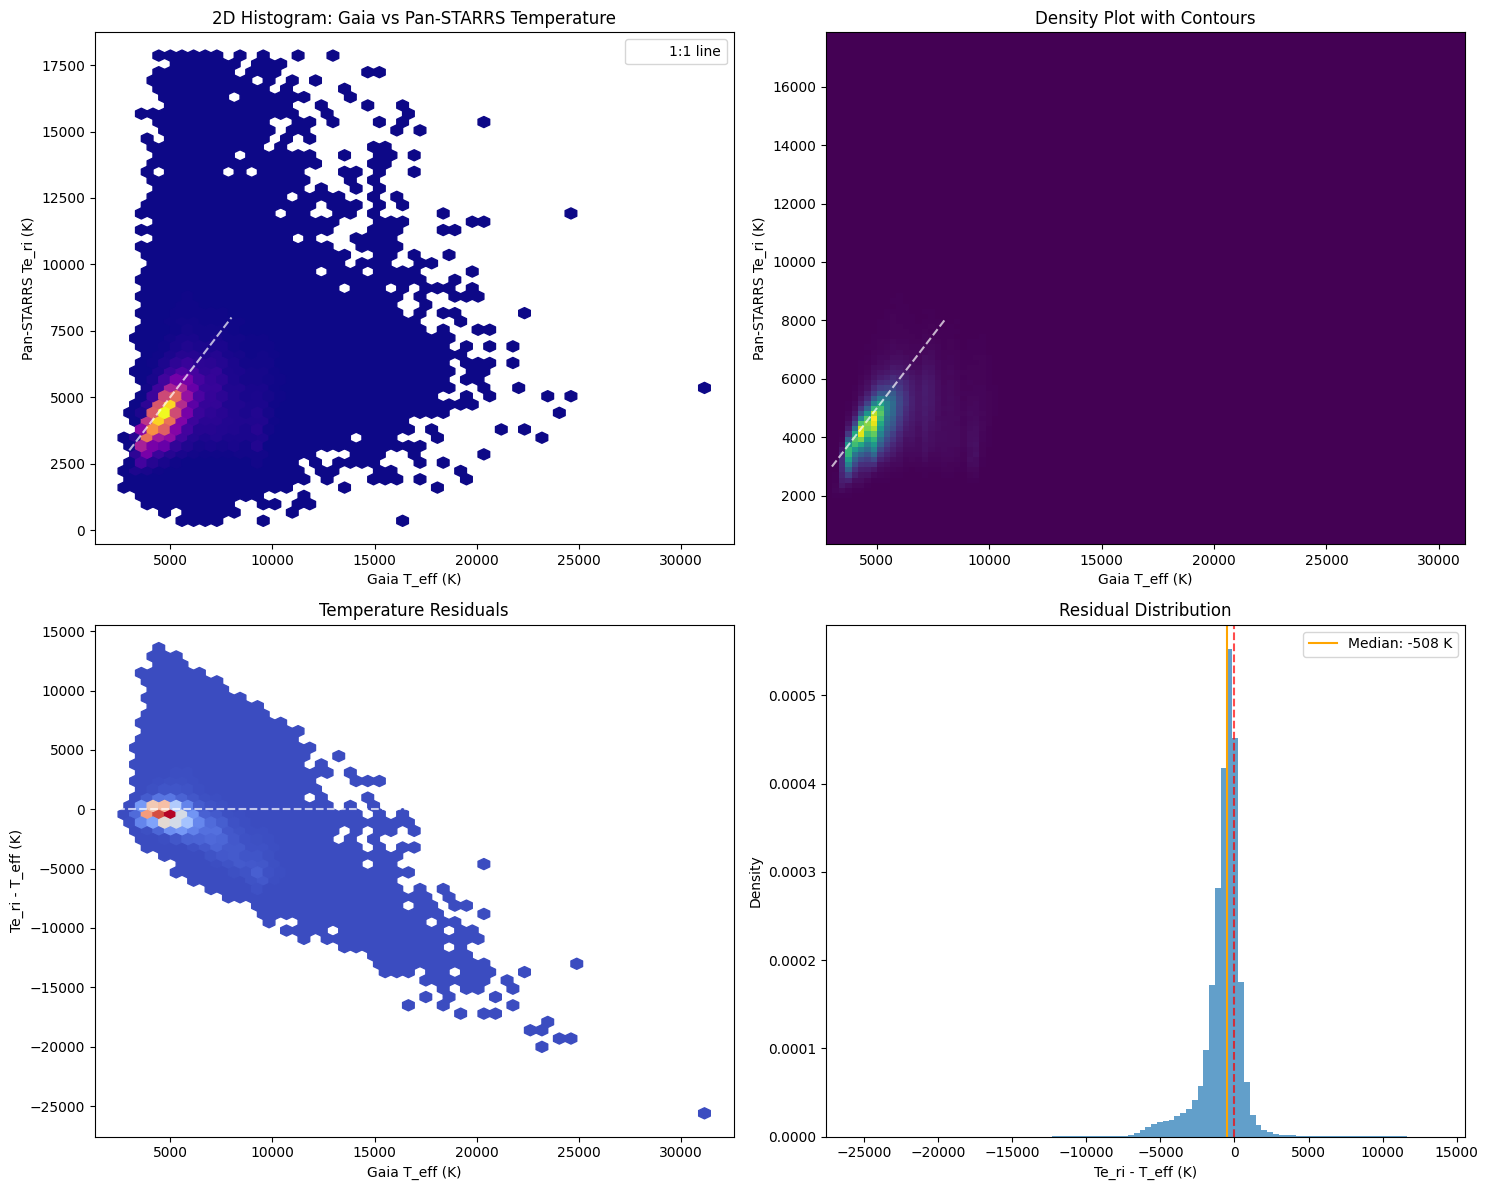


Temperature comparison statistics:
Gaia T_eff range: 2737 - 31144 K
Pan-STARRS Te_ri range: 347 - 17857 K
Median residual (Te_ri - T_eff): -508 K
MAD residual: 523 K
RMS residual: 1602 K


In [4]:
# Plot Gaia T_eff vs Pan-STARRS Te_ri
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_ri'] != -999.0)
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Pan-STARRS Te_ri: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_ri'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Pan-STARRS Te_ri (K)')
axes[0,0].set_title('2D Histogram: Gaia vs Pan-STARRS Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_ri'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Pan-STARRS Te_ri (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_ri'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_ri - T_eff (K)')
axes[1,0].set_title('Temperature Residuals')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_ri - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics:")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Pan-STARRS Te_ri range: {temp_data['Te_ri'].min():.0f} - {temp_data['Te_ri'].max():.0f} K")
print(f"Median residual (Te_ri - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")

Objects with both Gaia T_eff and Pan-STARRS Te_iz: 709,017


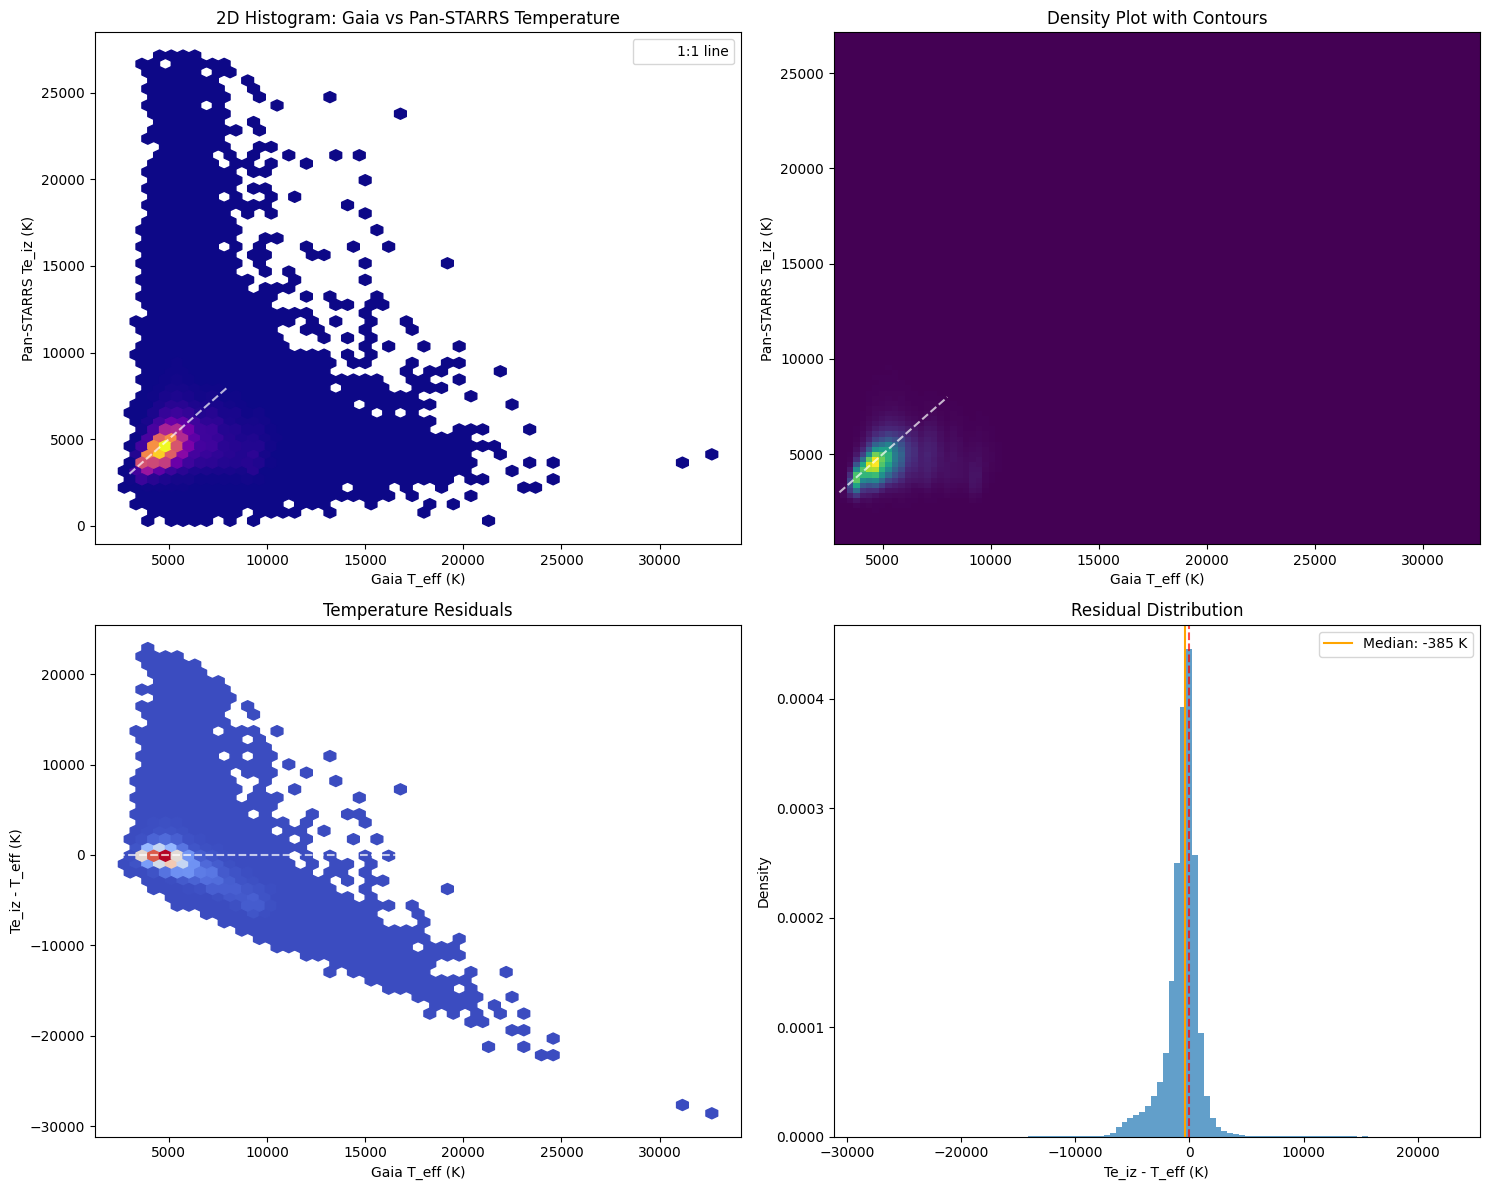


Temperature comparison statistics:
Gaia T_eff range: 2737 - 32657 K
Pan-STARRS Te_iz range: 285 - 27143 K
Median residual (Te_iz - T_eff): -385 K
MAD residual: 634 K
RMS residual: 1756 K


In [5]:
# Plot Gaia T_eff vs Pan-STARRS Te_iz
# Filter for valid temperature measurements
valid_temp = (merged['teff_gspphot'] > 0) & (merged['Te_iz'] != -999.0)
temp_data = merged[valid_temp]

print(f"Objects with both Gaia T_eff and Pan-STARRS Te_iz: {len(temp_data):,}")

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 2D histogram (hexbin plot)
axes[0,0].hexbin(temp_data['teff_gspphot'], temp_data['Te_iz'],
                gridsize=50, cmap='plasma', mincnt=1)
axes[0,0].set_xlabel('Gaia T_eff (K)')
axes[0,0].set_ylabel('Pan-STARRS Te_iz (K)')
axes[0,0].set_title('2D Histogram: Gaia vs Pan-STARRS Temperature')
axes[0,0].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7, label='1:1 line')
axes[0,0].legend()

# Density plot with contours
axes[0,1].hist2d(temp_data['teff_gspphot'], temp_data['Te_iz'],
                bins=100, cmap='viridis', density=True)
axes[0,1].set_xlabel('Gaia T_eff (K)')
axes[0,1].set_ylabel('Pan-STARRS Te_iz (K)')
axes[0,1].set_title('Density Plot with Contours')
axes[0,1].plot([3000, 8000], [3000, 8000], 'w--', alpha=0.7)

# Residuals vs Gaia T_eff
residuals = temp_data['Te_iz'] - temp_data['teff_gspphot']
axes[1,0].hexbin(temp_data['teff_gspphot'], residuals,
                gridsize=50, cmap='coolwarm', mincnt=1)
axes[1,0].set_xlabel('Gaia T_eff (K)')
axes[1,0].set_ylabel('Te_iz - T_eff (K)')
axes[1,0].set_title('Temperature Residuals')
axes[1,0].axhline(y=0, color='white', linestyle='--', alpha=0.7)

# Distribution of residuals
axes[1,1].hist(residuals, bins=100, alpha=0.7, density=True)
axes[1,1].set_xlabel('Te_iz - T_eff (K)')
axes[1,1].set_ylabel('Density')
axes[1,1].set_title('Residual Distribution')
axes[1,1].axvline(x=0, color='red', linestyle='--', alpha=0.7)
axes[1,1].axvline(x=np.median(residuals), color='orange', linestyle='-',
                    label=f'Median: {np.median(residuals):.0f} K')
axes[1,1].legend()

plt.tight_layout()
plt.show()

# Print statistics
print(f"\nTemperature comparison statistics:")
print(f"Gaia T_eff range: {temp_data['teff_gspphot'].min():.0f} - {temp_data['teff_gspphot'].max():.0f} K")
print(f"Pan-STARRS Te_iz range: {temp_data['Te_iz'].min():.0f} - {temp_data['Te_iz'].max():.0f} K")
print(f"Median residual (Te_iz - T_eff): {np.median(residuals):.0f} K")
print(f"MAD residual: {np.median(np.abs(residuals - np.median(residuals))):.0f} K")
print(f"RMS residual: {np.sqrt(np.mean(residuals**2)):.0f} K")